In [24]:
!pip install xlrd openpyxl pandas numpy scipy matplotlib seaborn

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 確保防呆資料夾存在（回到上一層建立 outputs/figures）
os.makedirs('../outputs/figures', exist_ok=True)

# 2. 用 read_csv 來讀取這個披著 Excel 外皮的 CSV 檔
file_path = '../data/processed/extension_cleaned_data.xls'
df = pd.read_csv(file_path)

# 3. 檢查是否成功載入
print(f"🎉 成功讀取檔案！總共包含 {len(df)} 筆數據。")
print("欄位清單確認：", df.columns.tolist())

# 4. 顯示前五筆的關鍵變數
df[['Sad_Label', 'Sleep_Hours']].head()

🎉 成功讀取檔案！總共包含 12106 筆數據。
欄位清單確認： ['SadOrHopeless', 'Sleep', 'Sleep_Hours', 'Sad_Label']


,Sad_Label,Sleep_Hours
0,Sad / Hopeless,8.0
1,Not Sad,7.0
2,Sad / Hopeless,4.0
3,Sad / Hopeless,4.0
4,Not Sad,9.0


======= TWO-SAMPLE T-TEST STATISTICAL REPORT =======
Sad / Hopeless Group Mean Sleep: 6.48 hours (n=3581)
Not Sad Group Mean Sleep: 6.93 hours (n=8525)
Observed Mean Difference (Sad - Not Sad): -0.44 hours
T-Statistic: -15.9326
P-Value: 0.0000
95% Confidence Interval for Difference: [-0.4982, -0.3891]



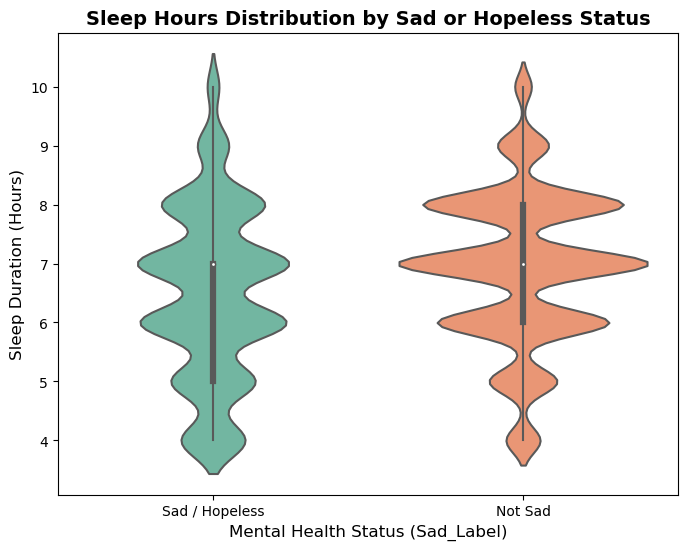

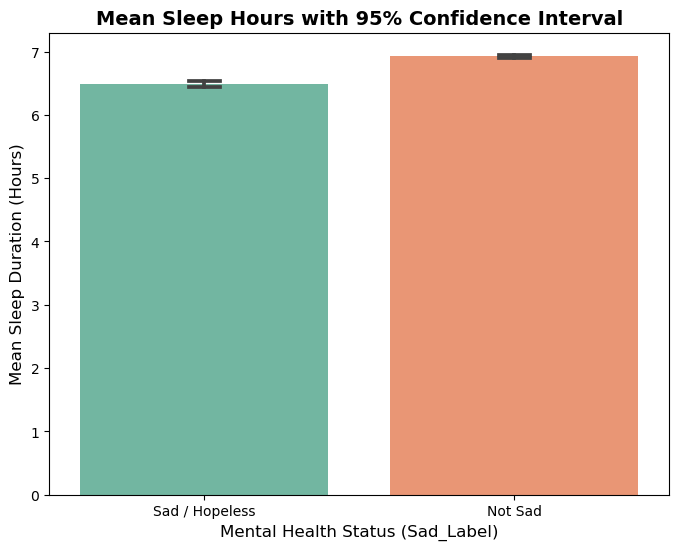

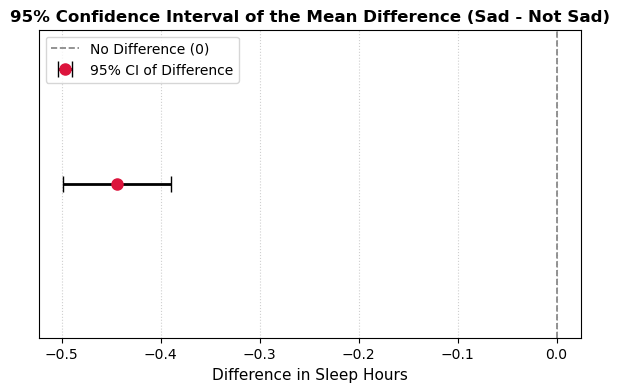

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Split data into distinct groups using correct categorical labels
group_sad = df[df['Sad_Label'] == 'Sad / Hopeless']['Sleep_Hours']
group_nosad = df[df['Sad_Label'] == 'Not Sad']['Sleep_Hours']

# 2. Perform independent two-sample t-test (Welch's t-test)
t_stat, p_value = stats.ttest_ind(group_sad, group_nosad, equal_var=False)

# 3. Calculate means and the observed difference
mean_sad = group_sad.mean()
mean_nosad = group_nosad.mean()
mean_diff = mean_sad - mean_nosad 

# 4. Calculate 95% Confidence Interval (CI) for the mean difference
n_sad, n_nosad = len(group_sad), len(group_nosad)
var_sad, var_nosad = group_sad.var(ddof=1), group_nosad.var(ddof=1)

se_diff = np.sqrt((var_sad / n_sad) + (var_nosad / n_nosad))
df_welch = ((var_sad/n_sad + var_nosad/n_nosad)**2) / ( ((var_sad/n_sad)**2 / (n_sad-1)) + ((var_nosad/n_nosad)**2 / (n_nosad-1)) )

t_critical = stats.t.ppf(0.975, df_welch)
ci_lower = mean_diff - (t_critical * se_diff)
ci_upper = mean_diff + (t_critical * se_diff)

# Print Statistical Inference Report
print("======= TWO-SAMPLE T-TEST STATISTICAL REPORT =======")
print(f"Sad / Hopeless Group Mean Sleep: {mean_sad:.2f} hours (n={n_sad})")
print(f"Not Sad Group Mean Sleep: {mean_nosad:.2f} hours (n={n_nosad})")
print(f"Observed Mean Difference (Sad - Not Sad): {mean_diff:.2f} hours")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"95% Confidence Interval for Difference: [{ci_lower:.4f}, {ci_upper:.4f}]\n")

# =======================================================
# 5. Plot and Save Figure 1: Violin Plot
# =======================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.violinplot(x='Sad_Label', y='Sleep_Hours', data=df, palette='Set2', ax=ax1)
ax1.set_title('Sleep Hours Distribution by Sad or Hopeless Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mental Health Status (Sad_Label)', fontsize=12)
ax1.set_ylabel('Sleep Duration (Hours)', fontsize=12)
fig1.savefig('../outputs/figures/01_violin_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# =======================================================
# 6. Plot and Save Figure 2: Bar Plot with 95% CI Error Bars
# =======================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.barplot(x='Sad_Label', y='Sleep_Hours', data=df, palette='Set2', errorbar=('ci', 95), capsize=0.1, ax=ax2)
ax2.set_title('Mean Sleep Hours with 95% Confidence Interval', fontsize=14, fontweight='bold')
ax2.set_xlabel('Mental Health Status (Sad_Label)', fontsize=12)
ax2.set_ylabel('Mean Sleep Duration (Hours)', fontsize=12)
fig2.savefig('../outputs/figures/02_barplot_ci.png', dpi=300, bbox_inches='tight')
plt.show()

# =======================================================
# 7. Plot and Save Figure 3: 95% Confidence Interval of Difference
# =======================================================
fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.errorbar(x=[mean_diff], y=[0], xerr=[[mean_diff - ci_lower], [ci_upper - mean_diff]], 
            fmt='o', color='crimson', ecolor='black', elinewidth=2, capsize=6, markersize=8, label='95% CI of Difference')
ax3.axvline(x=0, color='gray', linestyle='--', linewidth=1.2, label='No Difference (0)')
ax3.set_title('95% Confidence Interval of the Mean Difference (Sad - Not Sad)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Difference in Sleep Hours', fontsize=11)
ax3.set_yticks([]) 
ax3.legend()
ax3.grid(axis='x', linestyle=':', alpha=0.6)
fig3.savefig('../outputs/figures/03_mean_diff_ci.png', dpi=300, bbox_inches='tight')
plt.show() 